# Instalación de Dependencias
Ejecuta esta celda para instalar todas las librerías necesarias (Pandas, Streamlit, etc) desde tu entorno actual.

In [1]:
%pip install -r ../requirements.txt

     ---------------------------------------- 0.0/4.4 MB ? eta -:--:--
     -------------------------------------- - 4.2/4.4 MB 33.1 MB/s eta 0:00:01
     ---------------------------------------- 4.4/4.4 MB 26.2 MB/s  0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × installing build dependencies for pandas did not run successfully.
  │ exit code: 1
  ╰─> [57 lines of output]
           ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
           ------------------- -------------------- 7.6/15.8 MB 47.6 MB/s eta 0:00:01
           ---------------------------------------- 15.8/15.8 MB 55.5 MB/s  0:00:00
        Installing build dependencies: started
        Installing build dependencies: finished with status 'done'
        Getting requirements to build wheel: started
        Getting requirements to build wheel: finished with status 'done'
        Installing backend dependencies: started
        Installing backend dependencies: finished with status 'done'
        Preparing metadata (pyproject.toml): started
        Preparing metadata (pyproject.toml): finished with status 'error'
        error: subprocess-exited-with-error
      
        Ã— Preparing metadata (pyproject.toml) did not run s

# 1. Extracción (Extract)
Vamos a cargar el dataset de **California Housing Prices** que descargamos en la carpeta `data/raw/`.

In [3]:
import pandas as pd

# Cargar los datos crudos
df = pd.read_csv('../data/raw/housing.csv')

# Mostrar las primeras 5 filas
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## 2. Exploración Inicial
Veamos qué tipo de datos tenemos y si hay valores nulos.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB


## 3. Estadistica Descriptiva de variables Numericas
Veremos los valores minimos, maximos, promedios y cuartiles de las columnas numeros

In [5]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## 4. Conteo de valores para la variable categórica

In [ ]:
df["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

## 5. Conteo exacto de valores nulos por columna

In [7]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


# 6. Crear histogramas para las variables numéricas


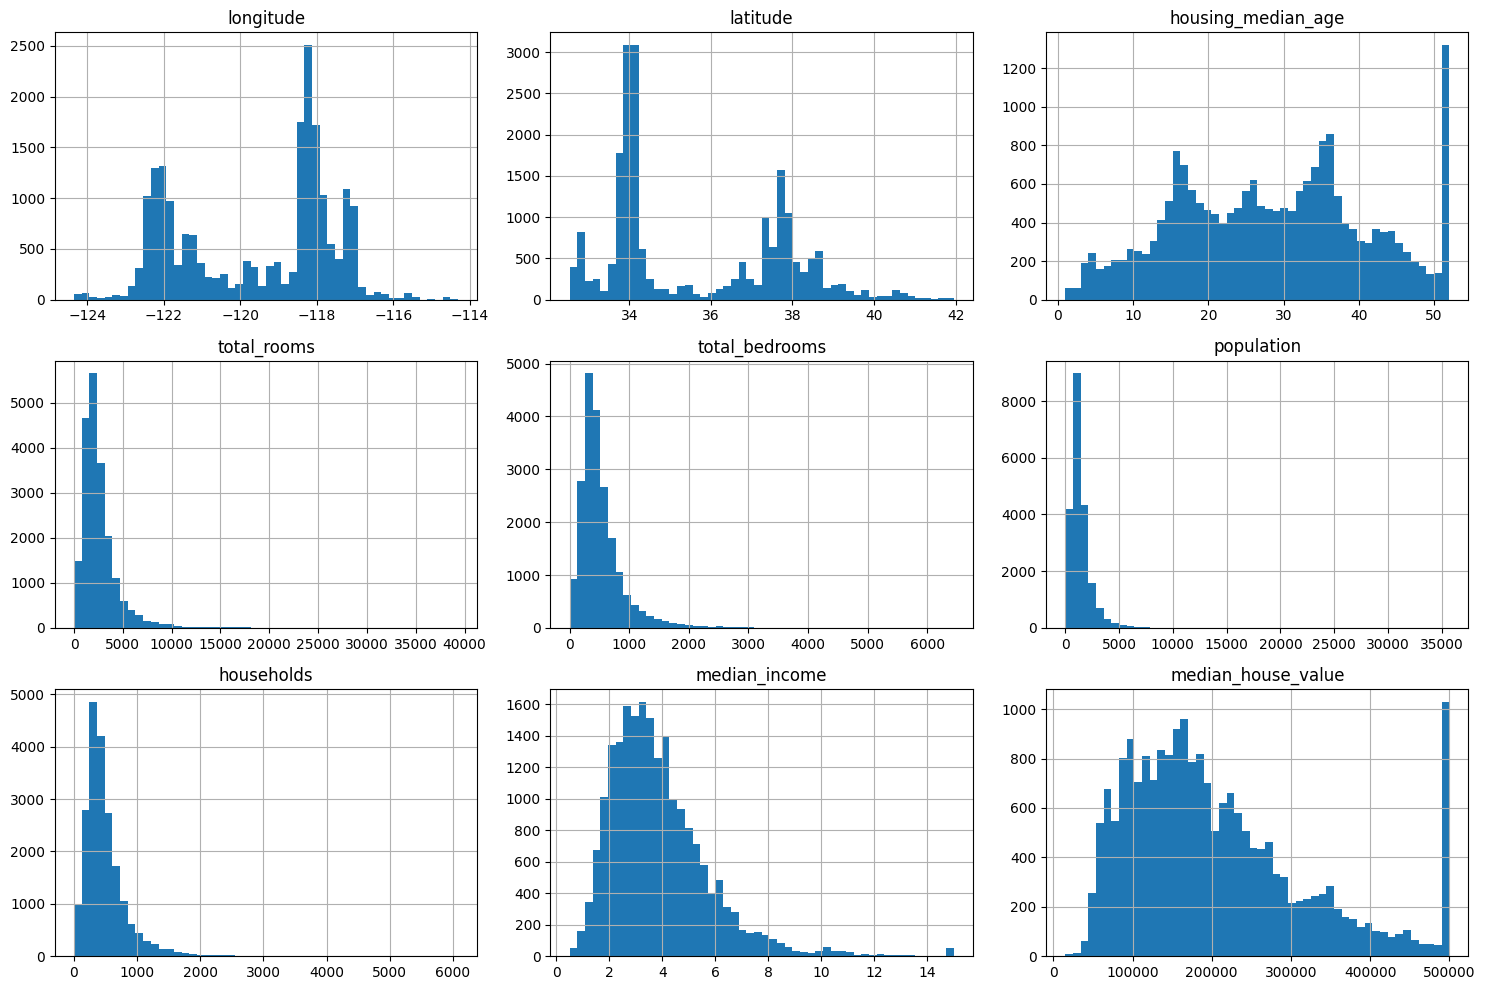

In [13]:
import matplotlib.pyplot as plt

df.hist(bins=50, figsize=(15, 10))
plt.tight_layout() # Para que no se superpongan los gráficos
plt.show()

## LIMPIEZA DE DATOS ETL 

In [21]:
# 1. Rellenar nulos con la mediana
mediana_habitaciones = df["total_bedrooms"].median()
df["total_bedrooms"] = df["total_bedrooms"].fillna(mediana_habitaciones)
# Verificamos que ya no haya nulos
print("Nulos restantes en total_bedrooms:", df["total_bedrooms"].isnull().sum())

df["total_bedrooms"]

Nulos restantes en total_bedrooms: 0


0         129.0
1        1106.0
2         190.0
3         235.0
4         280.0
          ...  
20635     374.0
20636     150.0
20637     485.0
20638     409.0
20639     616.0
Name: total_bedrooms, Length: 20640, dtype: float64

# 2. Crear nuevas métricas 

In [23]:
# 2. Crear nuevas métricas (Feature Engineering)
df["rooms_per_household"] = df["total_rooms"] / df["households"]
df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]
df["population_per_household"] = df["population"] / df["households"]
# Damos un vistazo a las nuevas columnas
df[["rooms_per_household", "bedrooms_per_room", "population_per_household"]]

,rooms_per_household,bedrooms_per_room,population_per_household
0,6.984127,0.146591,2.555556
1,6.238137,0.155797,2.109842
2,8.288136,0.129516,2.802260
3,5.817352,0.184458,2.547945
4,6.281853,0.172096,2.181467
...,...,...,...
20635,5.045455,0.224625,2.560606
20636,6.114035,0.215208,3.122807
20637,5.205543,0.215173,2.325635
20638,5.329513,0.219892,2.123209


# 3. Convertir variables categóricas (One-Hot Encoding)


In [24]:
df = pd.get_dummies(df, columns=["ocean_proximity"], dtype=int)
# Verificamos cómo quedó el dataset final
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   longitude                   20640 non-null  float64
 1   latitude                    20640 non-null  float64
 2   housing_median_age          20640 non-null  float64
 3   total_rooms                 20640 non-null  float64
 4   total_bedrooms              20640 non-null  float64
 5   population                  20640 non-null  float64
 6   households                  20640 non-null  float64
 7   median_income               20640 non-null  float64
 8   median_house_value          20640 non-null  float64
 9   rooms_per_household         20640 non-null  float64
 10  bedrooms_per_room           20640 non-null  float64
 11  population_per_household    20640 non-null  float64
 12  ocean_proximity_<1H OCEAN   20640 non-null  int64  
 13  ocean_proximity_INLAND      20640 non-null

## Cargar (Load).

In [25]:
# 1. Definir la ruta de destino
ruta_salida = '../data/processed/housing_clean.csv'
# 2. Guardar el DataFrame a un archivo CSV
df.to_csv(ruta_salida, index=False)
print(f"¡Éxito! Datos limpios guardados correctamente en: {ruta_salida}")

¡Éxito! Datos limpios guardados correctamente en: ../data/processed/housing_clean.csv
